In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns     
# water microplastic
# health monitorinng apart form test
# child monitor without internet tracking during kidnapped
# natural way of filtering of water 
# free education for north indias
# nitan agent 
# website for farmer to sell vegetables immediately or store it in container to improve the self life

import snowflake.connector

In [32]:
con=snowflake.connector.connect(user='haritha',password='aL8jFhz8hEs4F6Z',account='SCSCKVP-ZN24879',database='DB1',schema='PUBLIC',warehouse='COMPUTE_WH')
query='select * from "DB1"."PUBLIC"."WATER" '

In [3]:
df=pd.read_sql(query,con)
con.close()

C:\Users\USER\AppData\Local\Temp\ipykernel_3004\4011225180.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


In [4]:
df1=df.copy()

In [5]:
df.head()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [6]:
df.tail()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [8]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [9]:
df.isnull().sum()

PH                 491
HARDNESS             0
SOLIDS               0
CHLORAMINES          0
SULFATE            781
CONDUCTIVITY         0
ORGANIC_CARBON       0
TRIHALOMETHANES    162
TURBIDITY            0
POTABILITY           0
dtype: int64

In [10]:
df.shape

(3276, 10)

In [11]:
df.dtypes

PH                 float64
HARDNESS           float64
SOLIDS             float64
CHLORAMINES        float64
SULFATE            float64
CONDUCTIVITY       float64
ORGANIC_CARBON     float64
TRIHALOMETHANES    float64
TURBIDITY          float64
POTABILITY           int64
dtype: object

In [12]:
# Handle missing values
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy="mean") # All the data in featues were normally distributed
df['PH']=si.fit_transform(df[['PH']])
df['SULFATE']=si.fit_transform(df[['SULFATE']])
df['TRIHALOMETHANES']=si.fit_transform(df[['TRIHALOMETHANES']])

In [13]:
# Check null values
df.isnull().sum()

PH                 0
HARDNESS           0
SOLIDS             0
CHLORAMINES        0
SULFATE            0
CONDUCTIVITY       0
ORGANIC_CARBON     0
TRIHALOMETHANES    0
TURBIDITY          0
POTABILITY         0
dtype: int64

ValueError: num must be an integer with 1 <= num <= 9, not 10

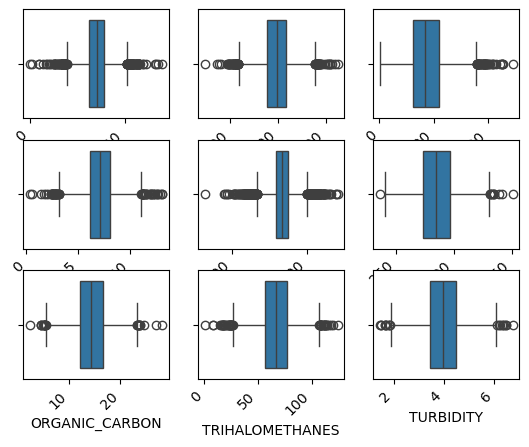

In [14]:
col=df.columns.tolist()
for i in range(len(col)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[col[i]])
    plt.xticks(rotation=45,ha="right")

ValueError: num must be an integer with 1 <= num <= 9, not 10

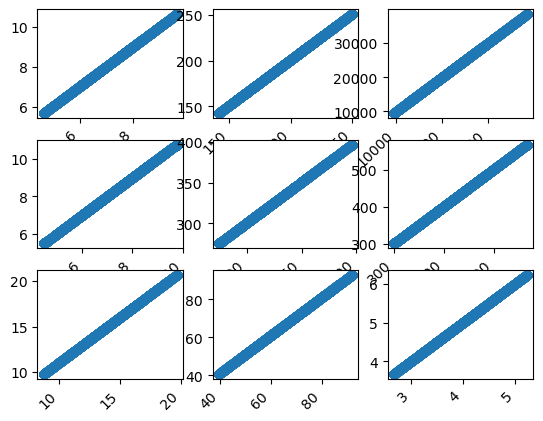

In [45]:
col=df.columns.tolist()
for i in range(len(col)-1):
    plt.subplot(3,3,i+1)
    plt.scatter(x=df[col[i]],y=df[col[i]]+1)
    plt.xticks(rotation=45,ha="right")

In [15]:
import numpy as np
from scipy.stats.mstats import winsorize
cols = ['PH','HARDNESS','SOLIDS','CHLORAMINES',
        'SULFATE','CONDUCTIVITY',
        'ORGANIC_CARBON',
        'TRIHALOMETHANES','TURBIDITY']
for col in cols:
    # Winsorize column
    df[col] = winsorize(df[col], limits=[0.05, 0.05])
    
    # Apply log transformation safely
    df[col + '1'] = np.log1p(df[col])

In [16]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY,PH1,HARDNESS1,SOLIDS1,CHLORAMINES1,SULFATE1,CONDUCTIVITY1,ORGANIC_CARBON1,TRIHALOMETHANES1,TURBIDITY1
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,2.089490,5.327344,9.942339,2.116281,5.912195,6.337372,2.431838,4.477234,1.377035
1,4.681099,141.622395,18630.057858,6.635246,333.775777,566.379397,15.180013,56.329076,4.500656,0,1.737145,4.960201,9.832585,2.032775,5.813461,6.341028,2.783777,4.048808,1.704867
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0,2.208178,5.417150,9.899005,2.329800,5.813461,6.039317,2.883047,4.210943,1.400181
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,91.851938,4.628771,0,2.231816,5.372373,9.999680,2.203795,5.880215,5.897886,2.967154,4.531006,1.727891
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,39.842379,4.075075,0,2.311765,5.204564,9.797015,2.021097,5.740229,5.989990,2.530380,3.709720,1.624341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3271,4.681099,193.681735,38494.720246,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,1.737145,5.271366,10.558302,2.100057,5.888735,6.268005,2.700987,4.214904,1.693011
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.637893,66.396293,2.798243,1,2.175758,5.270706,9.760241,2.204019,5.813461,5.974953,3.027129,4.210590,1.334539
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1,2.343680,5.174808,10.408996,2.122289,5.813461,6.070841,2.488157,4.260500,1.458353
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1,1.812667,5.445028,9.391400,1.988334,5.813461,6.001126,2.498887,4.362948,1.741984


In [17]:
df.columns

Index(['PH', 'HARDNESS', 'SOLIDS', 'CHLORAMINES', 'SULFATE', 'CONDUCTIVITY',
       'ORGANIC_CARBON', 'TRIHALOMETHANES', 'TURBIDITY', 'POTABILITY', 'PH1',
       'HARDNESS1', 'SOLIDS1', 'CHLORAMINES1', 'SULFATE1', 'CONDUCTIVITY1',
       'ORGANIC_CARBON1', 'TRIHALOMETHANES1', 'TURBIDITY1'],
      dtype='object')

In [18]:
import math
col=['PH1','HARDNESS1', 'SOLIDS1', 'CHLORAMINES1', 'SULFATE1', 'CONDUCTIVITY1',
       'ORGANIC_CARBON1', 'TRIHALOMETHANES1', 'TURBIDITY1']
n=len(col)
rows=math.ceil(n/3)

ValueError: num must be an integer with 1 <= num <= 9, not 10

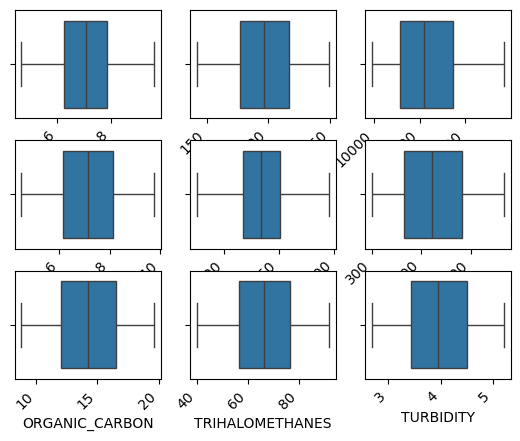

In [19]:
#Find outliers
col=df.columns.tolist()
for i in range(len(col)):
    plt.subplot(rows,3,i+1)
    sns.boxplot(x=df[col[i]])
    plt.xticks(rotation=45, ha='right')

In [20]:
x=df.drop('POTABILITY',axis=1)
y=df['POTABILITY']

In [21]:
df=df.replace('inf',0)

In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [24]:
model=SVC(kernel='linear')

In [28]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
m=model.fit(xtrain,ytrain)

In [30]:
ypred=m.predict(xtest)

In [34]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(ytest,ypred)

0.6219512195121951

In [39]:
cm=confusion_matrix(ytest,ypred)
cm

array([[407,   5],
       [243,   1]])

In [40]:
cr=classification_report(ytest,ypred)
cr

'              precision    recall  f1-score   support\n\n           0       0.63      0.99      0.77       412\n           1       0.17      0.00      0.01       244\n\n    accuracy                           0.62       656\n   macro avg       0.40      0.50      0.39       656\nweighted avg       0.46      0.62      0.48       656\n'

<Axes: >

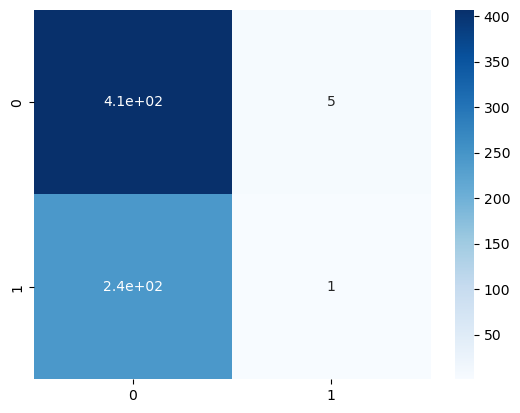

In [42]:
sns.heatmap(cm, annot=True, cmap='Blues')

In [47]:
df4=df.drop_duplicates()


In [48]:
df4.isnull().sum()

PH                  0
HARDNESS            0
SOLIDS              0
CHLORAMINES         0
SULFATE             0
CONDUCTIVITY        0
ORGANIC_CARBON      0
TRIHALOMETHANES     0
TURBIDITY           0
POTABILITY          0
PH1                 0
HARDNESS1           0
SOLIDS1             0
CHLORAMINES1        0
SULFATE1            0
CONDUCTIVITY1       0
ORGANIC_CARBON1     0
TRIHALOMETHANES1    0
TURBIDITY1          0
dtype: int64